In [ ]:
import numpy as np
from pyscf import gto, scf, cc

####  test H2 monomers ####
a = 2 # bond length in a cluster
d = 4 # distance between each cluster
unit = 'b' # unit of length
na = 2 # size of a cluster (monomer)
nc = 1 # set as integer multiple of monomers
spin = 0 # spin per monomer
frozen = 0 # frozen orbital per monomer
elmt = 'N'
unit = 'B'
basis = 'sto6g'
atoms = ""
for n in range(nc*na):
    shift = ((n - n % na) // na) * (d-a)
    atoms += f"{elmt} {n*a+shift:.5f} 0.00000 0.00000 \n"
###########################

mol = gto.M(atom=atoms,
            basis="sto6g",
            verbose=4,
            unit=unit,
            symmetry=0,
            charge=0,
            spin=spin*nc,
            max_memory=40000,
            )

mf = scf.RHF(mol)
mf.kernel()

mycc = cc.CCSD(mf).set_frozen()
mycc.kernel()

et = mycc.ccsd_t()
print(f"CCSD(T) = {mycc.e_tot+et}")

# CASCI E = -108.670551762995  E(CI) = -31.7781404613648  S^2 = 0.0000000

System: uname_result(system='Linux', node='sharmagroup-rn', release='6.17.0-29-generic', version='#29~24.04.1-Ubuntu SMP PREEMPT_DYNAMIC Mon May 11 10:30:58 UTC 2', machine='x86_64')  Threads 16
Python 3.12.13 | packaged by Anaconda, Inc. | (main, Mar 19 2026, 20:20:58) [GCC 14.3.0]
numpy 2.4.4  scipy 1.17.1  h5py 3.16.0
Date: Tue Jun  2 13:57:26 2026
PySCF version 2.12.1
PySCF path  /home/sharmagroup/sharmagroup/pyscf
GIT ORIG_HEAD 3d1768f5e33b144b606c3d2c81c12ee54d794501
GIT HEAD (branch master) f0861da51f017364d8bbaa20b742a94f3733305f

[ENV] OLD_PYSCF_EXT_PATH /home/sharmagroup/sharmagroup/pyscf-forge:
[ENV] PYSCF_EXT_PATH /home/sharmagroup/sharmagroup/pyscf-forge:/home/sharmagroup/sharmagroup/pyscf-forge:
[CONFIG] conf_file None
[INPUT] verbose = 4
[INPUT] num. atoms = 2
[INPUT] num. electrons = 14
[INPUT] charge = 0
[INPUT] spin (= nelec alpha-beta = 2S) = 0
[INPUT] symmetry 0 subgroup None
[INPUT] Mole.unit = B
[INPUT] Symbol           X                Y                Z      uni

In [2]:
from afqmc import integral
integral.prep_integral(mycc, chol_cut=1e-5)


Preparing AFQMC calculation
Calculating Cholesky integrals
Finished calculating Cholesky integrals
Size of the correlation space:
Number of electrons:        [5, 5]
Number of basis functions:  8
Number of Cholesky vectors: 42


In [3]:
import h5py
from jax import numpy as jnp
from afqmc import cholesky, propagation
from afqmc.wavefunctions import rwfn_exp

def load_afqmc(options=None,
               amp_file="amplitudes.npz",
               chol_file="FCIDUMP_chol"):

    options["dt"] = options.get("dt", 0.005)
    options["eql_time"] = options.get("eql_time", 20)
    options["n_walkers"] = options.get("n_walkers", 50)
    options["n_prop_steps"] = options.get("n_prop_steps", 50)
    options["n_blocks"] = options.get("n_blocks", 500)
    options["seed"] = options.get("seed", np.random.randint(1, int(1e6)))
    options["n_exp_terms"] = options.get("n_exp_terms",6)
    options["walker_type"] = options.get("walker_type", "rhf")
    options["trial"] = options.get("trial", None)
    options["free_projection"] = options.get("free_projection", False)
    options["n_batch"] = options.get("n_batch", 1)
    options["max_error"] = options.get("max_error", 0.0)
    options["nchol_chunk"] = options.get("nchol_chunk", 100)
    options["max_memory"] = options.get("max_memory", 2000) # MB
    options["mix_precision"] = options.get("mix_precision", True)

    print("\nLoad system from Integral File")

    with h5py.File(chol_file, "r") as fh5:
        [nelec, norb, ms] = fh5["header"]
        spin_type = fh5["spin_type"][()]
        h0 = jnp.array(fh5.get("energy_core"))
        h1 = jnp.array(fh5.get("hcore"))
        chol = jnp.array(fh5.get("chol"))
        h1_mod = jnp.array(fh5.get("hcore_mod"))
    
    if isinstance(spin_type, bytes):
        spin_type = spin_type.decode()

    assert spin_type in ["restricted", "unrestricted"]

    if spin_type == 'restricted':
        h1 = jnp.array(h1).reshape(norb, norb)
        h1_mod = jnp.array(h1_mod).reshape(norb, norb)
        chol = jnp.array(chol).reshape(-1, norb, norb)

    elif spin_type == 'unrestricted':
        h1 = jnp.array(h1).reshape(2, norb, norb)
        h1_mod = jnp.array(h1_mod).reshape(2, norb, norb)
        chol = jnp.array(chol).reshape(2, -1, norb, norb)

    assert type(ms) is np.int64
    assert type(nelec) is np.int64
    assert type(norb) is np.int64

    ms, nelec, norb = int(ms), int(nelec), int(norb)
    nelec_sp = ((nelec + abs(ms)) // 2, (nelec - abs(ms)) // 2)

    ham_data = {}
    ham_data["h0"] = h0

    if spin_type == 'restricted':
        ham_data["h1"] = jnp.array([h1, h1])
        ham_data["h1_mod"] = jnp.array(h1_mod)
        nchol = chol.shape[0]
        ham_data["chol"] = jnp.array(chol.reshape(chol.shape[0], -1))
    elif spin_type == 'unrestricted':
        ham_data["h1"] = jnp.array(h1)
        ham_data["h1_mod"] = jnp.array(h1_mod)
        nchol = chol[0].shape[0]
        ham_data["chol"] = jnp.array([chol[0].reshape(chol[0].shape[0], -1),
                                      chol[1].reshape(chol[1].shape[0], -1)])
        # ham_data["chol"] = [jnp.array(chol[0]), jnp.array(chol[1])]

    options["nchol_chunk"] = cholesky.chunk_chol(
        chol, options["nchol_chunk"], options["max_memory"]/options["n_walkers"])

    wave_data = {}
    mo_coeff = jnp.array([np.eye(norb),np.eye(norb)])

    if spin_type == "restricted":
        nocc = nelec_sp[0]
        wave_data["mo_coeff"] = mo_coeff[0][:,:nocc]
        wave_data["nelec"] = nelec_sp
        wave_data["norb"] = norb
        wave_data["nchol"] = nchol
        wave_data["rdm1"] = jnp.array([wave_data["mo_coeff"] @ wave_data["mo_coeff"].T] * 2)
        amplitudes = np.load(amp_file)
        t1 = jnp.array(amplitudes["t1"])
        t2 = jnp.array(amplitudes["t2"])
        ci2 = t2 + jnp.einsum("ia,jb->iajb", t1, t1)
        wave_data["ci1"] = t1
        wave_data["ci2"] = ci2
        
    print("\nQMC System")
    print(f"Number of electrons: {nelec_sp}")
    print(f"Spin Multiplicity:   {ms}")
    print(f"Number of orbitals:  {norb}")
    print(f"Number of Chol:      {nchol}")

    print("\nQMC Parameters")
    for op in options:
        if options[op] is not None:
            print(f"{str(op):<20s}: {str(options[op]):>20s}")

    return ham_data, wave_data, options

In [4]:
options = {'eql_time': 10,
            'n_blocks': 100,
            'n_walkers': 300,
            'max_error': 0.0,
            'mix_precision': False,
            'seed': 17,
            'walker_type': 'rhf',
            'trial': 'pt2ccsd',
            }

ham_data, wave_data, options = load_afqmc(options)


Load system from Integral File
Maximum memory per walker:            6.67 MB
Maximum number of Cholesky per chunk: 6826
Number of Cholesky chunks:            1
Number of Cholesky per chunk:         42
Number of padding Cholesky:           0

QMC System
Number of electrons: (5, 5)
Spin Multiplicity:   0
Number of orbitals:  8
Number of Chol:      42

QMC Parameters
eql_time            :                   10
n_blocks            :                  100
n_walkers           :                  300
max_error           :                  0.0
mix_precision       :                False
seed                :                   17
walker_type         :                  rhf
trial               :              pt2ccsd
dt                  :                0.005
n_prop_steps        :                   50
n_exp_terms         :                    6
free_projection     :                False
n_batch             :                    1
nchol_chunk         :                   42
max_memory          :         

In [5]:
from jax import random

def init_prop_data(
    trial,
    wave_data: dict,
    ham_data: dict,
    options: dict,
) -> dict:
    prop_data = {}
    prop_data["n_killed_walkers"] = 0
    prop_data["key"] = random.PRNGKey(options["seed"])
    prop_data["weights"] = jnp.ones(options["n_walkers"])
    prop_data["walkers"] = jnp.array([wave_data["mo_coeff"]]*options["n_walkers"], dtype=jnp.complex128)
    energies = jnp.real(trial.calc_energy(prop_data["walkers"], ham_data, wave_data))
    guide_olps = trial.calc_overlap(prop_data["walkers"], wave_data)
    trial_olps = trial.calc_trial_overlap(prop_data["walkers"], wave_data)
    olp_ratio = trial_olps / guide_olps
    weights_p = prop_data["weights"] * olp_ratio
    e_estimate = (jnp.sum(weights_p * energies) / jnp.sum(weights_p)).real
    prop_data["e_estimate"] = e_estimate
    prop_data["pop_control_ene_shift"] = e_estimate
    prop_data["overlaps"] = guide_olps
    return prop_data

In [6]:
from afqmc.sampling import sampler_exp
from afqmc.wavefunctions import rhf_wfn, rcisd_wfn

prop = propagation.propagator_restricted(
        options["dt"], 
        options["n_walkers"], 
        options["n_exp_terms"],
        options["n_batch"]
    )

pure_rhf = rwfn_exp.rwfn(    
    guide_overlap_fn=rhf_wfn.r_overlap,
    trial_overlap_fn=rhf_wfn.r_overlap,
    force_bias_fn=rhf_wfn.r_force_bias,
    energy_fn=rhf_wfn.r_energy,
    nelec=wave_data["nelec"],
    norb=wave_data["norb"],
    nchol=wave_data["nchol"],
    nchol_chunk=options["nchol_chunk"],
    )

sampler = sampler_exp(
    options["n_prop_steps"],
    options["n_blocks"],
    n_chol=wave_data["nchol"],
    )

In [7]:
import time
import numpy as np
from afqmc import config
from functools import partial

print = partial(print, flush=True)
init_time = time.time()

# prep.print_start()
config.setup_jax()

ham_data = prop._build_propagation_intermediates(ham_data, pure_rhf, wave_data)
prop_data = init_prop_data(pure_rhf, wave_data, ham_data, options)

init_e = prop_data["e_estimate"]
init_w = np.sum(prop_data["weights"])

print("\nEquilibration")

print(f"{'inv_T':>5s}  "
      f"{'weight':>12s}  {'killW':>5s}  "
      f"{'weightp':>12s}  {'energy':>12s}  {'runTime':>8s}")

print(f"{0.:5.2f}  "
      f"{init_w:12.6f}  {0:5d}  "
      f"{init_w:12.6f}  {init_e:12.6f}  {time.time() - init_time:8.2f}")


block_time = prop.dt * sampler.n_prop_steps
# neql_block = int(-(-options["eql_time"] // block_time))
neql_block = 1000

weightsp = np.zeros(neql_block, dtype=np.complex128)
energies = np.zeros(neql_block, dtype=np.complex128)

for n in range(1, neql_block+1):
    prop_data, (wt, wp, e) \
        = sampler.block_sample(prop, pure_rhf, prop_data, ham_data, wave_data)
    
    weightsp[n-1] = wp
    energies[n-1] = e

    if (n+1) % (min(max(neql_block // 10, 1), 20)) == 0 and n > 0:
        nkill = prop_data["n_killed_walkers"]
        print(f"{(n+1)*block_time:5.2f}  "
              f"{wt.real:12.6f}  {nkill:5d}  "
              f"{wp.real:12.6f}  {e.real:12.6f}  "
              f"{time.time() - init_time:8.2f}")

Hostname:     sharmagroup-rn
System:       Linux
Node:         sharmagroup-rn
Release:      6.17.0-29-generic
Machine:      x86_64
Processor:    x86_64
JAX backend:  GPU
JAX devices:  [CudaDevice(id=0)]
Device kind:  NVIDIA GeForce RTX 5060 Ti
Platform:     gpu

Equilibration
inv_T        weight  killW       weightp        energy   runTime
 0.00    300.000000      0    300.000000   -108.523474      1.65
 5.00    301.863427      0    301.863427   -108.677142      5.12
10.00    301.808698      0    301.808698   -108.668999      5.56
15.00    302.345936      0    302.345936   -108.704494      6.00
20.00    301.912349      0    301.912349   -108.669087      6.44
25.00    301.999113      0    301.999113   -108.682883      6.88
30.00    301.165214      0    301.165214   -108.641940      7.32
35.00    301.848101      0    301.848101   -108.663030      7.76
40.00    302.249472      0    302.249472   -108.693725      8.20
45.00    301.517106      0    301.517106   -108.676259      8.65
50.00   

E = -108.670797 +/- 0.001134 Ha  (averaged over 921 blocks, t >= 20)


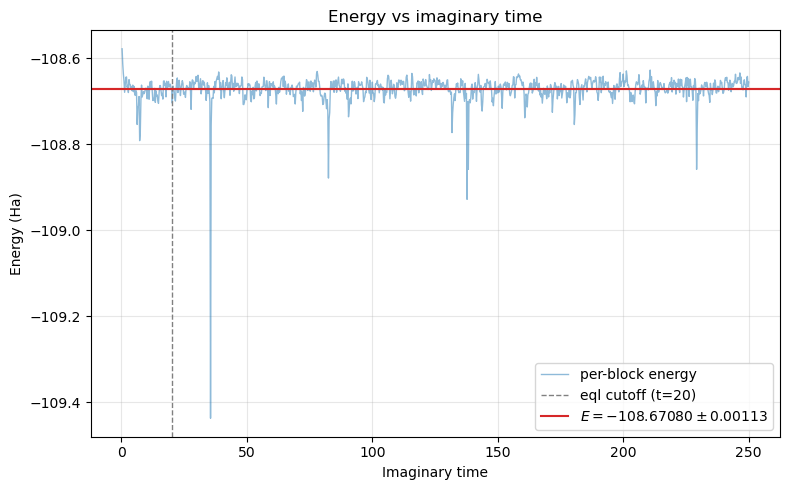

In [8]:
import matplotlib.pyplot as plt

imag_time = np.arange(1, neql_block + 1) * block_time

# --- discard equilibration, keep t >= 20 ---
mask = imag_time >= 20.0
w = weightsp[mask].real
e = energies[mask].real
N = len(e)

# weight-averaged energy
E_mean = np.sum(w * e) / np.sum(w)

# weighted variance (Bessel-corrected) -> std of the mean
wvar = np.sum(w * (e - E_mean) ** 2) / np.sum(w) * N / (N - 1)
sem = np.sqrt(wvar / N)

print(f"E = {E_mean:.6f} +/- {sem:.6f} Ha  (averaged over {N} blocks, t >= 20)")

# --- plot ---
plt.figure(figsize=(8, 5))
plt.plot(imag_time, energies.real, lw=1, alpha=0.5, label="per-block energy")

plt.axvline(20.0, color="gray", ls="--", lw=1, label="eql cutoff (t=20)")
plt.axhline(E_mean, color="C3", lw=1.5,
            label=fr"$E = {E_mean:.5f} \pm {sem:.5f}$")
plt.axhspan(E_mean - sem, E_mean + sem, color="C3", alpha=0.2)

plt.xlabel("Imaginary time")
plt.ylabel("Energy (Ha)")
plt.title("Energy vs imaginary time")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [9]:
rhf_guide_cisd = rwfn_exp.rwfn(    
    guide_overlap_fn=rcisd_wfn.r_overlap,
    trial_overlap_fn=rhf_wfn.r_overlap,
    force_bias_fn=rcisd_wfn.r_force_bias,
    energy_fn=rhf_wfn.r_energy,
    nelec=wave_data["nelec"],
    norb=wave_data["norb"],
    nchol=wave_data["nchol"],
    nchol_chunk=options["nchol_chunk"],
    )

In [10]:
import time
import numpy as np
from afqmc import config
from functools import partial

print = partial(print, flush=True)
init_time = time.time()

# prep.print_start()
config.setup_jax()

ham_data = prop._build_propagation_intermediates(ham_data, rhf_guide_cisd, wave_data)
prop_data = init_prop_data(rhf_guide_cisd, wave_data, ham_data, options)

init_e = prop_data["e_estimate"]
init_w = np.sum(prop_data["weights"])

print("\nEquilibration")

print(f"{'inv_T':>5s}  "
      f"{'weight':>12s}  {'killW':>5s}  "
      f"{'weightp':>12s}  {'energy':>12s}  {'runTime':>8s}")

print(f"{0.:5.2f}  "
      f"{init_w:12.6f}  {0:5d}  "
      f"{init_w:12.6f}  {init_e:12.6f}  {time.time() - init_time:8.2f}")


block_time = prop.dt * sampler.n_prop_steps
# neql_block = int(-(-options["eql_time"] // block_time))
neql_block = 1000

weightsp2 = np.zeros(neql_block, dtype=np.complex128)
energies2 = np.zeros(neql_block, dtype=np.complex128)

for n in range(1, neql_block+1):
    prop_data, (wt, wp, e) \
        = sampler.block_sample(prop, rhf_guide_cisd, prop_data, ham_data, wave_data)
    
    weightsp2[n-1] = wp
    energies2[n-1] = e

    if (n+1) % (min(max(neql_block // 10, 1), 20)) == 0 and n > 0:
        nkill = prop_data["n_killed_walkers"]
        print(f"{(n+1)*block_time:5.2f}  "
              f"{wt.real:12.6f}  {nkill:5d}  "
              f"{wp.real:12.6f}  {e.real:12.6f}  "
              f"{time.time() - init_time:8.2f}")

Hostname:     sharmagroup-rn
System:       Linux
Node:         sharmagroup-rn
Release:      6.17.0-29-generic
Machine:      x86_64
Processor:    x86_64
JAX backend:  GPU
JAX devices:  [CudaDevice(id=0)]
Device kind:  NVIDIA GeForce RTX 5060 Ti
Platform:     gpu

Equilibration
inv_T        weight  killW       weightp        energy   runTime
 0.00    300.000000      0    300.000000   -108.523474      0.93
 5.00    301.750963      0    282.986045   -108.649355      6.14
10.00    301.987159      0    282.980116   -108.646964      6.79
15.00    301.841635      0    276.435954   -108.700213      7.44
20.00    301.923587      0    282.830061   -108.652693      8.09
25.00    301.988354      0    281.301950   -108.666225      8.74
30.00    301.694546      0    281.764982   -108.655736      9.39
35.00    302.053385      0    282.184141   -108.654363     10.05
40.00    301.822920      0    279.545843   -108.675164     10.70
45.00    300.620783      0    278.012945   -108.677276     11.35
50.00   

E = -108.664938 +/- 0.000395 Ha  (averaged over 921 blocks, t >= 20)


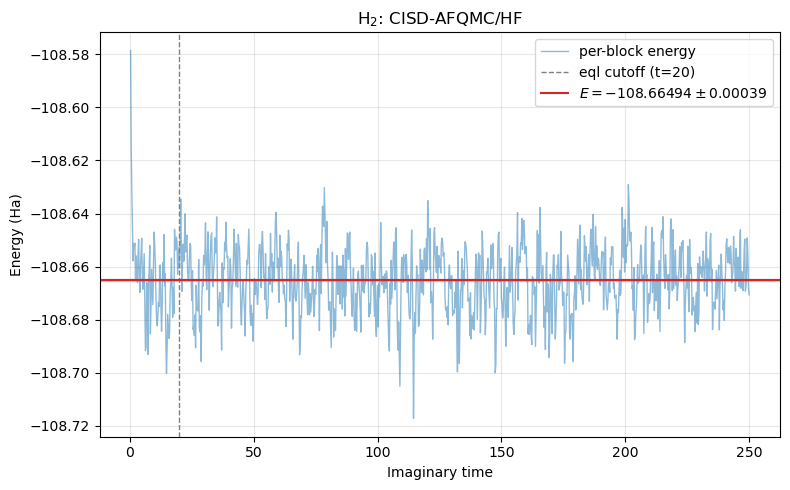

In [11]:
import matplotlib.pyplot as plt

imag_time = np.arange(1, neql_block + 1) * block_time

# --- discard equilibration, keep t >= 20 ---
mask = imag_time >= 20.0
w2 = weightsp2[mask].real
e2 = energies2[mask].real
N = len(e2)

# weight-averaged energy
E_mean2 = np.sum(w2 * e2) / np.sum(w2)

# weighted variance (Bessel-corrected) -> std of the mean
wvar2 = np.sum(w2 * (e2 - E_mean2) ** 2) / np.sum(w2) * N / (N - 1)
sem2 = np.sqrt(wvar2 / N)

print(f"E = {E_mean2:.6f} +/- {sem2:.6f} Ha  (averaged over {N} blocks, t >= 20)")

# --- plot ---
plt.figure(figsize=(8, 5))
plt.plot(imag_time, energies2.real, lw=1, alpha=0.5, label="per-block energy")

plt.axvline(20.0, color="gray", ls="--", lw=1, label="eql cutoff (t=20)")
plt.axhline(E_mean2, color="C3", lw=1.5,
            label=fr"$E = {E_mean2:.5f} \pm {sem2:.5f}$")
plt.axhspan(E_mean2 - sem2, E_mean2 + sem2, color="C3", alpha=0.2)

plt.xlabel("Imaginary time")
plt.ylabel("Energy (Ha)")
plt.title("H$_2$: CISD-AFQMC/HF")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

E = -108.670797 +/- 0.001134 Ha  (averaged over 921 blocks, t >= 20)


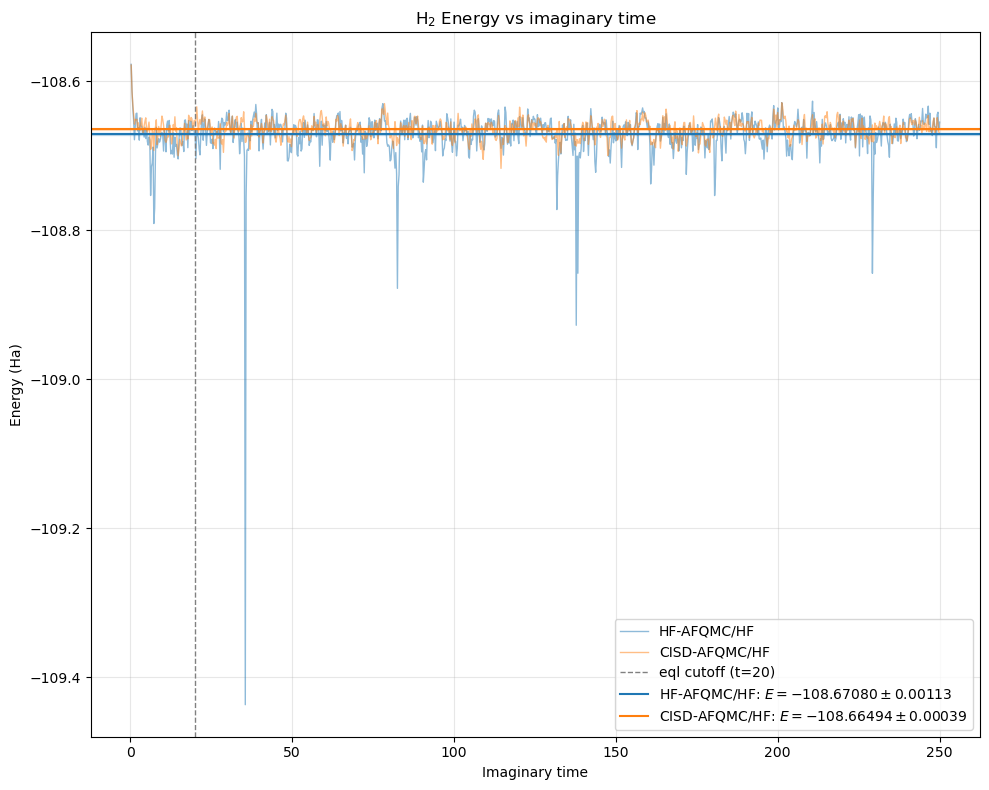

In [15]:
imag_time = np.arange(1, neql_block + 1) * block_time

# --- discard equilibration, keep t >= 20 ---
mask = imag_time >= 20.0
w = weightsp[mask].real
e = energies[mask].real
N = len(e)

# weight-averaged energy
E_mean = np.sum(w * e) / np.sum(w)

# weighted variance (Bessel-corrected) -> std of the mean
wvar = np.sum(w * (e - E_mean) ** 2) / np.sum(w) * N / (N - 1)
sem = np.sqrt(wvar / N)

print(f"E = {E_mean:.6f} +/- {sem:.6f} Ha  (averaged over {N} blocks, t >= 20)")

# --- plot ---
plt.figure(figsize=(10, 8))
plt.plot(imag_time, energies.real, lw=1, color="C0", alpha=0.5, label="HF-AFQMC/HF")
plt.plot(imag_time, energies2.real, lw=1, color="C1", alpha=0.5, label="CISD-AFQMC/HF")

plt.axvline(20.0, color="gray", ls="--", lw=1, label="eql cutoff (t=20)")
plt.axhline(E_mean, lw=1.5, color="C0", label=fr"HF-AFQMC/HF: $E = {E_mean:.5f} \pm {sem:.5f}$")
plt.axhspan(E_mean - sem, E_mean + sem, color="C0", alpha=0.2)
plt.axhline(E_mean2, lw=1.5, color="C1", label=fr"CISD-AFQMC/HF: $E = {E_mean2:.5f} \pm {sem2:.5f}$")
plt.axhspan(E_mean2 - sem2, E_mean2 + sem2, color="C1",alpha=0.2)

plt.xlabel("Imaginary time")
plt.ylabel("Energy (Ha)")
plt.title("H$_2$ Energy vs imaginary time")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [19]:
cisd_t_cisd_g = rwfn_exp.rwfn(    
    guide_overlap_fn=rcisd_wfn.r_overlap,
    trial_overlap_fn=rcisd_wfn.r_overlap,
    force_bias_fn=rcisd_wfn.r_force_bias,
    energy_fn=rcisd_wfn.r_energy,
    nelec=wave_data["nelec"],
    norb=wave_data["norb"],
    nchol=wave_data["nchol"],
    nchol_chunk=options["nchol_chunk"],
    )

import opt_einsum as oe
def _build_measurement_intermediates(trial, ham_data: dict, wave_data: dict) -> dict:
    ham_data["lci1"] = oe.contract(
        "git,pt->gip",
        ham_data["chol"].reshape(-1, trial.norb, trial.norb)[:, :, trial.nelec[0] :],
        wave_data["ci1"],
        backend="jax"
    )
    return ham_data

ham_data = _build_measurement_intermediates(cisd_t_cisd_g, ham_data, wave_data)

In [20]:
import time
import numpy as np
from afqmc import config
from functools import partial

print = partial(print, flush=True)
init_time = time.time()

# prep.print_start()
config.setup_jax()

ham_data = prop._build_propagation_intermediates(ham_data, cisd_t_cisd_g, wave_data)
prop_data = init_prop_data(cisd_t_cisd_g, wave_data, ham_data, options)

init_e = prop_data["e_estimate"]
init_w = np.sum(prop_data["weights"])

print("\nEquilibration")

print(f"{'inv_T':>5s}  "
      f"{'weight':>12s}  {'killW':>5s}  "
      f"{'weightp':>12s}  {'energy':>12s}  {'runTime':>8s}")

print(f"{0.:5.2f}  "
      f"{init_w:12.6f}  {0:5d}  "
      f"{init_w:12.6f}  {init_e:12.6f}  {time.time() - init_time:8.2f}")


block_time = prop.dt * sampler.n_prop_steps
# neql_block = int(-(-options["eql_time"] // block_time))
neql_block = 1000

weightsp3 = np.zeros(neql_block, dtype=np.complex128)
energies3 = np.zeros(neql_block, dtype=np.complex128)

for n in range(1, neql_block+1):
    prop_data, (wt, wp, e) \
        = sampler.block_sample(prop, cisd_t_cisd_g, prop_data, ham_data, wave_data)
    
    weightsp3[n-1] = wp
    energies3[n-1] = e

    if (n+1) % (min(max(neql_block // 10, 1), 20)) == 0 and n > 0:
        nkill = prop_data["n_killed_walkers"]
        print(f"{(n+1)*block_time:5.2f}  "
              f"{wt.real:12.6f}  {nkill:5d}  "
              f"{wp.real:12.6f}  {e.real:12.6f}  "
              f"{time.time() - init_time:8.2f}")

Hostname:     sharmagroup-rn
System:       Linux
Node:         sharmagroup-rn
Release:      6.17.0-29-generic
Machine:      x86_64
Processor:    x86_64
JAX backend:  GPU
JAX devices:  [CudaDevice(id=0)]
Device kind:  NVIDIA GeForce RTX 5060 Ti
Platform:     gpu

Equilibration
inv_T        weight  killW       weightp        energy   runTime
 0.00    300.000000      0    300.000000   -108.666985      1.51
 5.00    299.593483      0    299.593483   -108.666554      6.99
10.00    299.827990      0    299.827990   -108.669300      7.70
15.00    299.683507      0    299.683507   -108.673680      8.41
20.00    299.764874      0    299.764874   -108.669027      9.12
25.00    299.829177      0    299.829177   -108.667655      9.83
30.00    299.537470      0    299.537470   -108.667447     10.54
35.00    299.893743      0    299.893743   -108.666221     11.25
40.00    299.664926      0    299.664926   -108.668533     11.97
45.00    299.540842      0    299.540842   -108.676370     12.68
50.00   

E = -108.670115 +/- 0.000090 Ha  (averaged over 921 blocks, t >= 20)


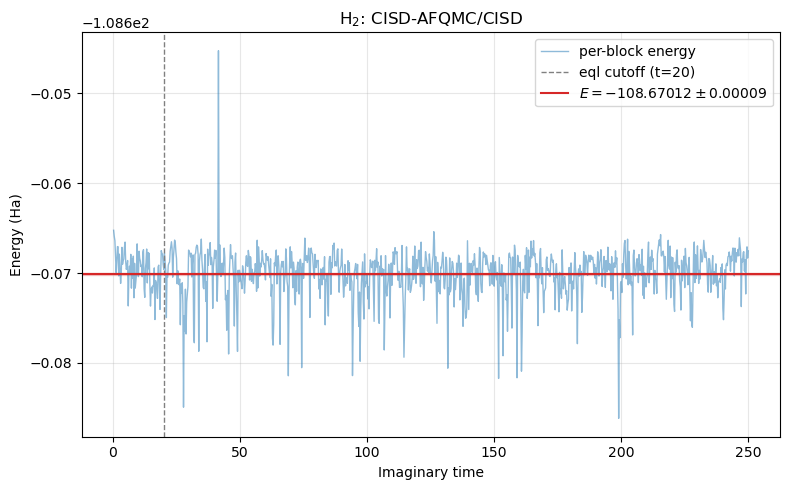

In [21]:
imag_time = np.arange(1, neql_block + 1) * block_time

# --- discard equilibration, keep t >= 20 ---
mask = imag_time >= 20.0
w3 = weightsp3[mask].real
e3 = energies3[mask].real
N = len(e3)

# weight-averaged energy
E_mean3 = np.sum(w3 * e3) / np.sum(w3)

# weighted variance (Bessel-corrected) -> std of the mean
wvar3 = np.sum(w3 * (e3 - E_mean3) ** 2) / np.sum(w3) * N / (N - 1)
sem3 = np.sqrt(wvar3 / N)

print(f"E = {E_mean3:.6f} +/- {sem3:.6f} Ha  (averaged over {N} blocks, t >= 20)")

# --- plot ---
plt.figure(figsize=(8, 5))
plt.plot(imag_time, energies3.real, lw=1, alpha=0.5, label="per-block energy")

plt.axvline(20.0, color="gray", ls="--", lw=1, label="eql cutoff (t=20)")
plt.axhline(E_mean3, color="C3", lw=1.5,
            label=fr"$E = {E_mean3:.5f} \pm {sem3:.5f}$")
plt.axhspan(E_mean3 - sem3, E_mean3 + sem3, color="C3", alpha=0.2)

plt.xlabel("Imaginary time")
plt.ylabel("Energy (Ha)")
plt.title("H$_2$: CISD-AFQMC/CISD")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [22]:
cisd_t_rhf_g = rwfn_exp.rwfn(    
    guide_overlap_fn=rhf_wfn.r_overlap,
    trial_overlap_fn=rcisd_wfn.r_overlap,
    force_bias_fn=rhf_wfn.r_force_bias,
    energy_fn=rcisd_wfn.r_energy,
    nelec=wave_data["nelec"],
    norb=wave_data["norb"],
    nchol=wave_data["nchol"],
    nchol_chunk=options["nchol_chunk"],
    )

import opt_einsum as oe
def _build_measurement_intermediates(trial, ham_data: dict, wave_data: dict) -> dict:
    ham_data["lci1"] = oe.contract(
        "git,pt->gip",
        ham_data["chol"].reshape(-1, trial.norb, trial.norb)[:, :, trial.nelec[0] :],
        wave_data["ci1"],
        backend="jax"
    )
    return ham_data

ham_data = _build_measurement_intermediates(cisd_t_cisd_g, ham_data, wave_data)

In [23]:
import time
import numpy as np
from afqmc import config
from functools import partial

print = partial(print, flush=True)
init_time = time.time()

# prep.print_start()
config.setup_jax()

ham_data = prop._build_propagation_intermediates(ham_data, cisd_t_rhf_g, wave_data)
prop_data = init_prop_data(cisd_t_rhf_g, wave_data, ham_data, options)

init_e = prop_data["e_estimate"]
init_w = np.sum(prop_data["weights"])

print("\nEquilibration")

print(f"{'inv_T':>5s}  "
      f"{'weight':>12s}  {'killW':>5s}  "
      f"{'weightp':>12s}  {'energy':>12s}  {'runTime':>8s}")

print(f"{0.:5.2f}  "
      f"{init_w:12.6f}  {0:5d}  "
      f"{init_w:12.6f}  {init_e:12.6f}  {time.time() - init_time:8.2f}")


block_time = prop.dt * sampler.n_prop_steps
# neql_block = int(-(-options["eql_time"] // block_time))
neql_block = 1000

weightsp4 = np.zeros(neql_block, dtype=np.complex128)
energies4 = np.zeros(neql_block, dtype=np.complex128)

for n in range(1, neql_block+1):
    prop_data, (wt, wp, e) \
        = sampler.block_sample(prop, cisd_t_rhf_g, prop_data, ham_data, wave_data)
    
    weightsp4[n-1] = wp
    energies4[n-1] = e

    if (n+1) % (min(max(neql_block // 10, 1), 20)) == 0 and n > 0:
        nkill = prop_data["n_killed_walkers"]
        print(f"{(n+1)*block_time:5.2f}  "
              f"{wt.real:12.6f}  {nkill:5d}  "
              f"{wp.real:12.6f}  {e.real:12.6f}  "
              f"{time.time() - init_time:8.2f}")

Hostname:     sharmagroup-rn
System:       Linux
Node:         sharmagroup-rn
Release:      6.17.0-29-generic
Machine:      x86_64
Processor:    x86_64
JAX backend:  GPU
JAX devices:  [CudaDevice(id=0)]
Device kind:  NVIDIA GeForce RTX 5060 Ti
Platform:     gpu

Equilibration
inv_T        weight  killW       weightp        energy   runTime
 0.00    300.000000      0    300.000000   -108.666985      1.18
 5.00    299.705143      0    323.117383   -108.670084      6.20
10.00    299.650806      0    322.459725   -108.669410      6.70
15.00    300.184203      0    329.014703   -108.670489      7.21
20.00    299.753716      0    321.958375   -108.669254      7.71
25.00    299.839859      0    323.425548   -108.667489      8.22
30.00    299.011923      0    316.919970   -108.666553      8.72
35.00    299.689927      0    321.612631   -108.666981      9.23
40.00    300.088428      0    325.457280   -108.671497      9.73
45.00    299.361299      0    322.295825   -108.669716     10.24
50.00   

E = -108.669720 +/- 0.000245 Ha  (averaged over 921 blocks, t >= 20)


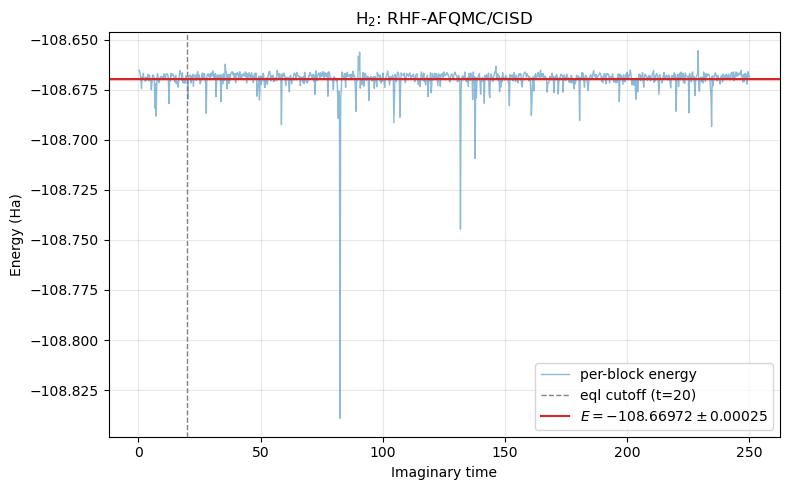

In [24]:
imag_time = np.arange(1, neql_block + 1) * block_time

# --- discard equilibration, keep t >= 20 ---
mask = imag_time >= 20.0
w4 = weightsp4[mask].real
e4 = energies4[mask].real
N = len(e4)

# weight-averaged energy
E_mean4 = np.sum(w4 * e4) / np.sum(w4)

# weighted variance (Bessel-corrected) -> std of the mean
wvar4 = np.sum(w4 * (e4 - E_mean4) ** 2) / np.sum(w4) * N / (N - 1)
sem4 = np.sqrt(wvar4 / N)

print(f"E = {E_mean4:.6f} +/- {sem4:.6f} Ha  (averaged over {N} blocks, t >= 20)")

# --- plot ---
plt.figure(figsize=(8, 5))
plt.plot(imag_time, energies4.real, lw=1, alpha=0.5, label="per-block energy")

plt.axvline(20.0, color="gray", ls="--", lw=1, label="eql cutoff (t=20)")
plt.axhline(E_mean4, color="C3", lw=1.5,
            label=fr"$E = {E_mean4:.5f} \pm {sem4:.5f}$")
plt.axhspan(E_mean4 - sem4, E_mean4 + sem4, color="C3", alpha=0.2)

plt.xlabel("Imaginary time")
plt.ylabel("Energy (Ha)")
plt.title("H$_2$: RHF-AFQMC/CISD")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()